<a href="https://colab.research.google.com/github/shahab335khan-ship-it/ml-test/blob/main/24F_BSAI_139__OPEN__ENDED_HOUSE_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OPEN ENDED LAB

ROLL NO: 24F-BSAI-139            SHAHAB AHMED KHAN        
PROJECT HOUSE PREDICTION             
MACHINE LEARNING     

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
files.upload()
df=pd.read_csv("train.csv")
print(df.shape)
df.head(5)

Saving train.csv to train.csv
(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df.info()
print("duplicates",df.duplicated().sum())
df["SalePrice"].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


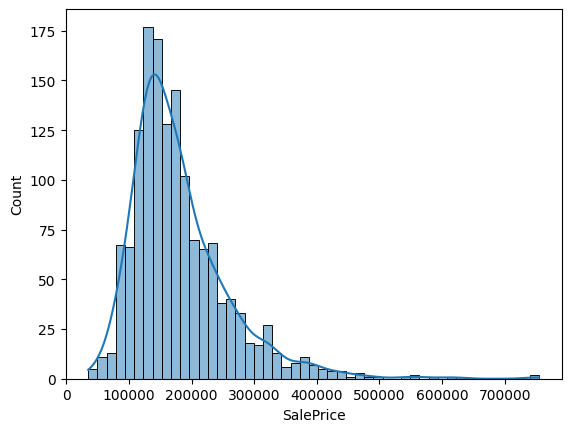

SalePrice       1.000000
OverallQual     0.795774
GrLivArea       0.734968
TotalBsmtSF     0.651153
GarageCars      0.641047
1stFlrSF        0.631530
GarageArea      0.629217
FullBath        0.562165
TotRmsAbvGrd    0.537769
YearBuilt       0.523608
Name: SalePrice, dtype: float64


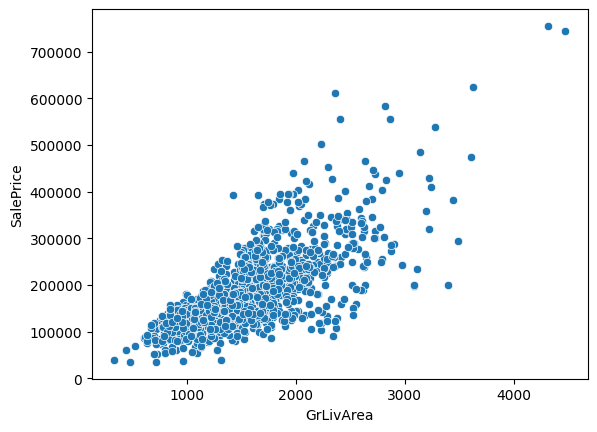

In [49]:
# price ka graph: ek taraf jhuka hua hai (skewed), isay baad mein log se theek karenge
sns.histplot(df["SalePrice"], kde=True)
plt.show()

# SalePrice ke saath sabse zyada relation wali top 10 columns
print(df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False).head(10))

# Rehne ki jagah (GrLivArea) vs qeemat: 2 ghar bohot bade lekin sasta, ye outliers hain
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.show()

In [ ]:
df = df.drop("Id", axis=1)# ye is lie alg likh ahai because mene is ko ikdfa drop kr dia hai dobara chalane pr error arha hai

In [24]:
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
             "BsmtFinType2", "MasVnrType"]
df[none_cols]=df[none_cols].fillna("None")
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])


In [28]:
print("pehele jo shape thi ",df.shape)
df=df[~((df["GrLivArea"]>4000) & (df["SalePrice"]<300000))]
print("bad mein jo shape ai ",df.shape)

pehele jo shape thi  (1458, 80)
bad mein jo shape ai  (1458, 80)


category
Medium    489
Low       486
High      483
Name: count, dtype: int64
hadein [ 34900. 139567. 190000. 755000.]


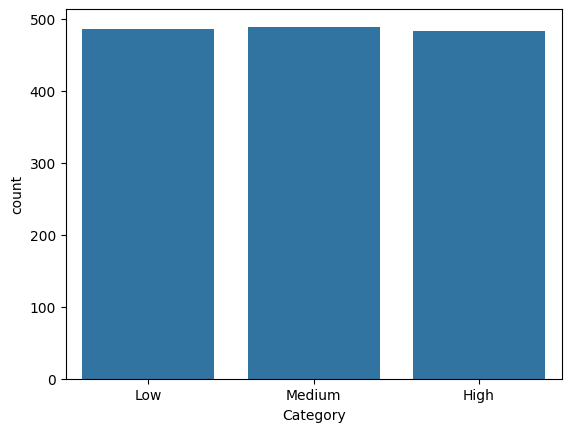

In [32]:
df["Category"],bins=pd.qcut(df["SalePrice"],3,labels=["Low","Medium","High"],retbins=True)
print(df["category"].value_counts())
print("hadein",bins.round(0))
sns.countplot(x="Category", data=df)
plt.show()


In [50]:
# Target 1: qeemat (log lagayi taake graph seedha ho jaye), regression ke liye
y_price = np.log1p(df["SalePrice"])

# Target 2: category (Low/Medium/High), classification ke liye
y_cat = df["Category"]

# Features (X): dono targets hata do, warna model jawab dekh kar cheating karega
X = df.drop(["SalePrice", "Category"], axis=1)

# Encoding: text columns ko 0/1 numbers mein badlo (models sirf numbers samajhte hain)
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(1458, 260)


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ek hi split se dono targets ko 80% train aur 20% test mein baanto
# order: pehle train, phir test (yp = y price, yc = y category)
X_train, X_test, yp_train, yp_test, yc_train, yc_test = train_test_split(
    X, y_price, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

# Scaling: sab features ko ek jaisi scale par lao
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit sirf train par
X_test = scaler.transform(X_test)         # test par sirf transform

# Check: train bada (1166), test chhota (292)
print(X_train.shape, X_test.shape)
print(len(yp_train), len(yp_test))
print(len(yc_train), len(yc_test))

(1166, 260) (292, 260)
1166 292
1166 292


In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Linear Regression: features se seedhi line bana kar qeemat predict karta hai
lr = LinearRegression()

# Training data par seekho
lr.fit(X_train, yp_train)

# Test data ki qeemat predict karo
lr_pred = lr.predict(X_test)

# R2: 1 ke jitna qareeb, model utna acha. RMSE: average ghalti
print("R2 (log scale):", r2_score(yp_test, lr_pred))
print("RMSE (log scale):", np.sqrt(mean_squared_error(yp_test, lr_pred)))

# Log hata kar asli dollar mein wapas lao
actual = np.expm1(yp_test)
predicted = np.expm1(lr_pred)

print("R2 (dollar):", r2_score(actual, predicted))
print("MAE (dollar):", mean_absolute_error(actual, predicted))

R2 (log scale): 0.9100819291189586
RMSE (log scale): 0.11972609660312264
R2 (dollar): 0.9393711563505931
MAE (dollar): 13636.553825769546


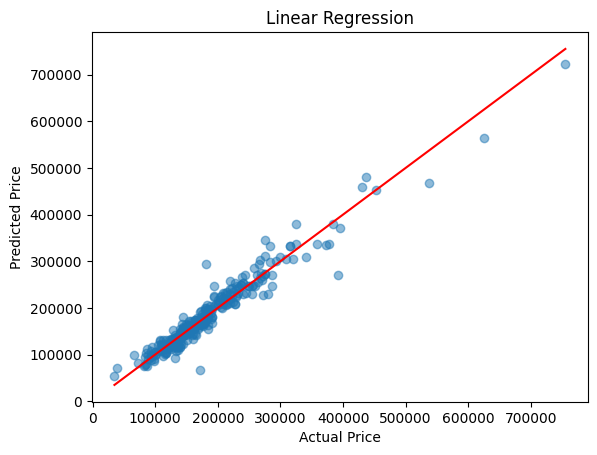

In [42]:
plt.scatter(actual, predicted, alpha=0.5)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], "r")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression")
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Random Forest: bohot saare trees milkar vote karte hain ke ghar Low hai, Medium hai ya High
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Model ko training data par seekhne do (features + asli category)
rf.fit(X_train, yc_train)

# Ab test data (jo model ne kabhi nahi dekha) ki category predict karo
rf_pred = rf.predict(X_test)

# Accuracy: kitne andaze sahi nikle
print("Random Forest Accuracy:", accuracy_score(yc_test, rf_pred))

Random Forest Accuracy: 0.9931506849315068


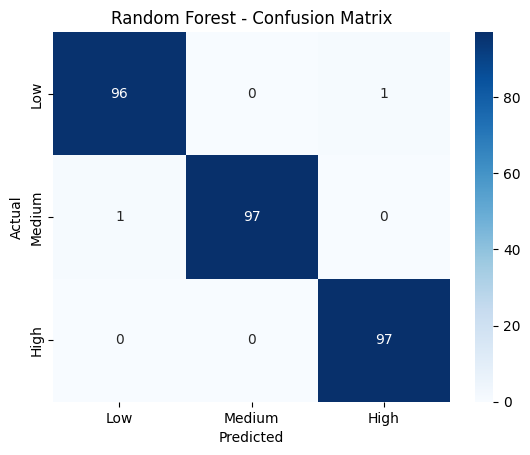

              precision    recall  f1-score   support

         Low       0.99      0.99      0.99        97
      Medium       1.00      0.99      0.99        98
        High       0.99      1.00      0.99        97

    accuracy                           0.99       292
   macro avg       0.99      0.99      0.99       292
weighted avg       0.99      0.99      0.99       292



In [45]:
labels = ["Low", "Medium", "High"]

# Confusion matrix: rows = asli category, columns = model ki predict ki hui category
cm = confusion_matrix(yc_test, rf_pred, labels=labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Har category ka precision, recall aur f1-score
print(classification_report(yc_test, rf_pred, labels=labels))

In [46]:
# Dono models ka muqabla ek table mein
# Linear Regression ko R2 se naapte hain, Random Forest ko accuracy se
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Task": ["Price (regression)", "Category (classification)"],
    "Metric": ["R2", "Accuracy"],
    "Score": [r2_score(actual, predicted),
              accuracy_score(yc_test, rf_pred)]})
print(comparison.round(3))

               Model                       Task    Metric  Score
0  Linear Regression         Price (regression)        R2  0.939
1      Random Forest  Category (classification)  Accuracy  0.993


In [47]:
# Linear Regression ki predict ki hui price se category banao
# wahi Low / Medium / High ki hadein use karo jo pehle banayi thi
pred_category = pd.cut(predicted,
                       bins=[0, bins[1], bins[2], np.inf],
                       labels=["Low", "Medium", "High"])

# Category nikalne ke dono tareeqon ko compare karo
print("Accuracy (predicted price se nikli category):", accuracy_score(yc_test, pred_category))
print("Accuracy (Random Forest classifier se):", accuracy_score(yc_test, rf_pred))

Accuracy (predicted price se nikli category): 0.9315068493150684
Accuracy (Random Forest classifier se): 0.9931506849315068


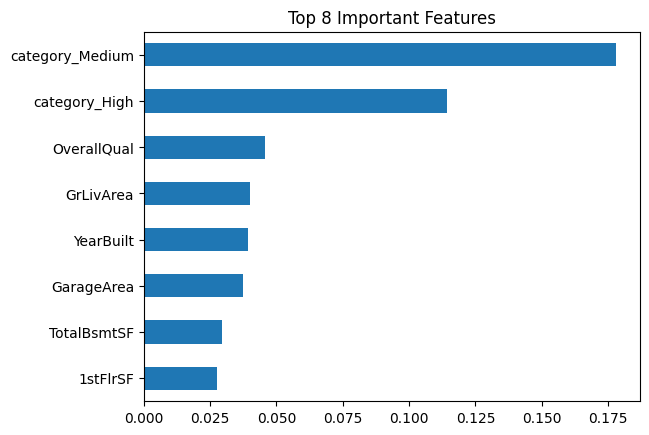

In [48]:
# Random Forest ke hisaab se kaunsi features sabse zyada kaam ki
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

imp.head(8).plot(kind="barh")
plt.title("Top 8 Important Features")
plt.gca().invert_yaxis()   # sabse important feature sabse upar
plt.show()